In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
from constants import *
from sc_scripts import *
from preprocessor import Preprocessor

path_10x = PROJ_ROOT / '3v3_10x'
path_smartseq = PROJ_ROOT / 'GSE135045'

smartseq_files = [file for file in os.listdir(path_smartseq) if file.endswith('.txt.gz')]

## Features: chromosome arms + whole 7/10 contrast

- map CPM genes → autosomal **arms** (`1p`,`1q`,… including `7p/7q` and `10p/10q` when present)
- acrocentric arms without genes are simply absent (feature count may be < 45)
- after shares: add whole `7 = 7p+7q`, `10 = 10p+10q`, and `diff_7_minus_10 = 7 - 10`

**Norm fork** (after arm aggregation, before shares):
- `cpm_shares` — no log
- `cpm_agg_log_shares` — `log1p` on arm totals, then shares

In [ ]:
import importlib
import preprocessor
importlib.reload(preprocessor)
from preprocessor import Preprocessor

# --- choose normalization fork ---
NORM_MODE = "cpm_agg_log_shares"          # or "cpm_agg_log_shares"
FEATURE_MODE = "arms_plus_710"    # arms + whole 7/10 + diff_7_minus_10

sc_loader = Preprocessor()

chr_means_10x = sc_loader.run_pipeline(
    path_10x,
    _10x=True,
    feature_mode=FEATURE_MODE,
    norm_mode=NORM_MODE,
    add_qc=False,
)

chr_means_smartseq_list = []
for file in smartseq_files:
    df = sc_loader.run_pipeline(
        path_smartseq / file,
        _10x=False,
        feature_mode=FEATURE_MODE,
        norm_mode=NORM_MODE,
        add_qc=False,
    )
    chr_means_smartseq_list.append(df)

chr_means_smartseq = pd.concat(chr_means_smartseq_list, axis=1)
print("10x:", chr_means_10x.shape, "| smartseq:", chr_means_smartseq.shape)
print("features:", chr_means_10x.index.tolist())

Running pipeline for /Users/neuropromotion/Desktop/GCF/new_approach/3v3_10x | features=arms_plus_710 | norm=cpm_shares
Running pipeline for /Users/neuropromotion/Desktop/GCF/new_approach/GSE135045/sample_2.txt.gz | features=arms_plus_710 | norm=cpm_shares
Running pipeline for /Users/neuropromotion/Desktop/GCF/new_approach/GSE135045/sample_4.txt.gz | features=arms_plus_710 | norm=cpm_shares
Running pipeline for /Users/neuropromotion/Desktop/GCF/new_approach/GSE135045/sample_6.txt.gz | features=arms_plus_710 | norm=cpm_shares
Running pipeline for /Users/neuropromotion/Desktop/GCF/new_approach/GSE135045/sample_3.txt.gz | features=arms_plus_710 | norm=cpm_shares
Running pipeline for /Users/neuropromotion/Desktop/GCF/new_approach/GSE135045/sample_1.txt.gz | features=arms_plus_710 | norm=cpm_shares
Running pipeline for /Users/neuropromotion/Desktop/GCF/new_approach/GSE135045/sample_5.txt.gz | features=arms_plus_710 | norm=cpm_shares
Running pipeline for /Users/neuropromotion/Desktop/GCF/new_

In [62]:
merged = pd.concat([chr_means_10x, chr_means_smartseq], axis=1)
# unique cell ids (barcodes can collide across samples/platforms)
merged.columns = pd.RangeIndex(merged.shape[1])

# drop QC-like rows if any slipped in; keep arms + 7/10 + diff
keep = [
    r for r in merged.index.astype(str)
    if r.endswith(("p", "q"))
    or r in {"7", "10", "diff_7_minus_10"}
]
merged = merged.loc[keep]
print(merged.shape, "features x cells")
print(merged.index.tolist())
merged.drop(['22p'], axis=0, inplace=True)


mask = (
    merged.index.str.endswith(('p', 'q')) &
    ~merged.index.str[:-1].isin(['7', '10'])
)

df = (
    merged[mask]
    .rename(index=lambda x: x[:-1])  # убрать p/q
    .groupby(level=0)
    .sum()
)
result = pd.concat([merged[~mask], df]).sort_index()

result.drop(['7p', '10p', '7q', '10q'], axis=0, inplace=True)

result

(44, 27219) features x cells
['1p', '1q', '2p', '2q', '3p', '3q', '4p', '4q', '5p', '5q', '6p', '6q', '7p', '7q', '8p', '8q', '9p', '9q', '10p', '10q', '11p', '11q', '12p', '12q', '13q', '14q', '15q', '16p', '16q', '17p', '17q', '18p', '18q', '19p', '19q', '20p', '20q', '21p', '21q', '22q', '7', '10', 'diff_7_minus_10', '22p']


,0,1,2,3,4,5,6,7,8,9,...,27209,27210,27211,27212,27213,27214,27215,27216,27217,27218
feature,,,,,,,,,,,,,,,,,,,,,
1,0.085815,0.112610,0.097190,0.091476,0.087526,0.071514,0.091488,0.084811,0.131499,0.119033,...,0.110414,0.110307,0.135802,0.117955,0.097038,0.096305,0.102171,0.087730,0.107042,0.128761
10,0.015649,0.019514,0.046060,0.028893,0.012717,0.036097,0.022453,0.031915,0.016218,0.018814,...,0.030113,0.031947,0.022092,0.029489,0.017013,0.021199,0.013410,0.041104,0.035211,0.006619
11,0.092378,0.115235,0.132242,0.097111,0.089957,0.172825,0.127346,0.101433,0.110050,0.092506,...,0.062735,0.082580,0.075374,0.080603,0.179584,0.115082,0.058748,0.068712,0.098592,0.086041
12,0.062090,0.064033,0.049392,0.062223,0.064896,0.073727,0.037534,0.055482,0.061607,0.057171,...,0.061481,0.060880,0.076673,0.072084,0.054820,0.047850,0.068966,0.061350,0.045775,0.070999
13,0.030288,0.017664,0.027810,0.019902,0.018328,0.020773,0.014410,0.024379,0.018043,0.015009,...,0.028858,0.022303,0.012995,0.011140,0.012602,0.018776,0.012133,0.020859,0.020423,0.015042
14,0.021706,0.032941,0.031721,0.039444,0.033103,0.025711,0.040214,0.026817,0.032436,0.047842,...,0.037014,0.043400,0.022742,0.023591,0.026465,0.034525,0.021711,0.039264,0.049296,0.028279
15,0.056032,0.033359,0.030852,0.036446,0.026370,0.037970,0.023794,0.029699,0.025380,0.027100,...,0.024467,0.031344,0.022742,0.032110,0.026465,0.035736,0.026820,0.036810,0.043662,0.026474
16,0.051489,0.035567,0.022885,0.031051,0.044324,0.024689,0.018097,0.023124,0.027240,0.025849,...,0.018821,0.025919,0.033788,0.031455,0.021424,0.012720,0.027458,0.032515,0.030986,0.028881
17,0.055528,0.069941,0.095307,0.066659,0.062278,0.047676,0.105898,0.047207,0.057535,0.051021,...,0.067754,0.049427,0.055231,0.055701,0.049149,0.158692,0.076628,0.066871,0.078169,0.043923


In [63]:
merged = result

## Train 2D VAE

~40 arm/derived features → latent dim 2. Smaller MLP than for gene-level panels.

In [64]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import torch
import importlib
import vae
importlib.reload(vae)
from vae import VAEConfig, ChromosomeVAETrainer

device = "mps" if torch.backends.mps.is_available() else (
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)

feature_names = [str(r) for r in merged.index]
print("VAE features:", len(feature_names), feature_names)

config = VAEConfig(
    input_dim=len(feature_names),
    latent_dim=2,
    hidden_dims=(64, 32),      # ~40–45 inputs — keep small
    beta=0.01,
    beta_warmup_epochs=30,
    lr=1e-3,
    batch_size=512,
    epochs=150,
    dropout=0.05,
    min_detection_rate=0.0,    # dense arm features, no gene dropout filter
    preload_to_device=True,
    seed=42,
    feature_names=feature_names,
)

trainer = ChromosomeVAETrainer(config, device=device)
latent = trainer.fit_encode(merged, feature_names=feature_names)
latent.head()

Using device: mps
VAE features: 23 ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '3', '4', '5', '6', '7', '8', '9', 'diff_7_minus_10']
Train matrix: 27219 cells × 23 genes | device=mps
Preloaded training tensor on mps (2.5 MB)
epoch    1/150  beta=0.0003  loss=0.9609  recon=0.9608  kl=0.4353
epoch   10/150  beta=0.0033  loss=0.5226  recon=0.5091  kl=4.0493
epoch   20/150  beta=0.0067  loss=0.4878  recon=0.4677  kl=3.0108
epoch   30/150  beta=0.0100  loss=0.4839  recon=0.4559  kl=2.8010
epoch   40/150  beta=0.0100  loss=0.4750  recon=0.4468  kl=2.8170
epoch   50/150  beta=0.0100  loss=0.4674  recon=0.4392  kl=2.8214
epoch   60/150  beta=0.0100  loss=0.4639  recon=0.4355  kl=2.8416
epoch   70/150  beta=0.0100  loss=0.4587  recon=0.4302  kl=2.8456
epoch   80/150  beta=0.0100  loss=0.4557  recon=0.4271  kl=2.8554
epoch   90/150  beta=0.0100  loss=0.4513  recon=0.4228  kl=2.8527
epoch  100/150  beta=0.0100  loss=0.4513  recon=0.4228  kl=2.8456
epoc

,z1,z2
0,-0.044474,0.821845
1,0.860291,1.527167
2,-0.414286,0.944581
3,0.371381,0.387976
4,1.257925,0.910022


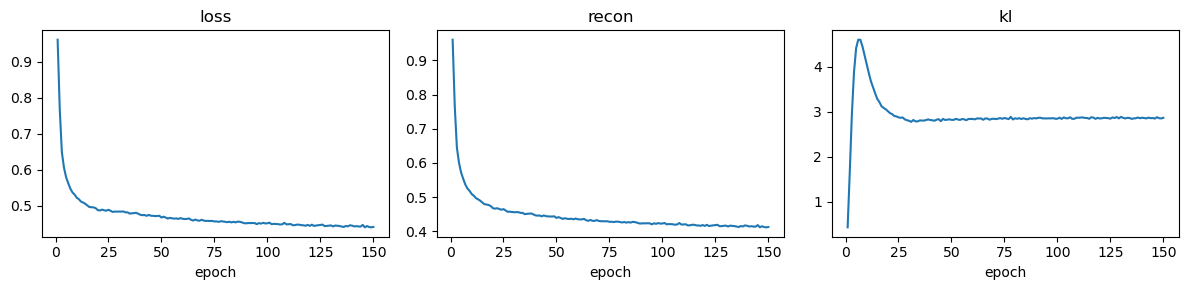

In [65]:
hist = pd.DataFrame(trainer.history)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, col in enumerate(["loss", "recon", "kl"]):
    ax[i].plot(hist["epoch"], hist[col])
    ax[i].set_title(col)
    ax[i].set_xlabel("epoch")
plt.tight_layout()
plt.show()

In [33]:
save_dir = PROJ_ROOT / "vae_checkpoints" / f"arms_vae_2d_{NORM_MODE}"
trainer.save(save_dir)
print("Saved to", save_dir)

# Inference into the same space:
# trainer2 = ChromosomeVAETrainer.load(save_dir)
# z_new = trainer2.encode(new_arm_matrix)

Saved to /Users/neuropromotion/Desktop/GCF/new_approach/vae_checkpoints/arms_vae_2d_cpm_agg_log_shares


## 2D latent space

Color = local density (unsupervised).

In [66]:
import plotly.express as px
from sklearn.neighbors import NearestNeighbors

rng = np.random.default_rng(42)
n_plot = min(22000, len(latent))
plot_idx = rng.choice(len(latent), size=n_plot, replace=False)
Z = latent.iloc[plot_idx][["z1", "z2"]].to_numpy()

nn = NearestNeighbors(n_neighbors=30).fit(Z)
dists, _ = nn.kneighbors(Z)
density = 1.0 / (dists[:, 1:].mean(axis=1) + 1e-8)

plot_df = latent.iloc[plot_idx][["z1", "z2"]].copy()
plot_df["density"] = density

fig = px.scatter(
    plot_df,
    x="z1",
    y="z2",
    color="density",
    opacity=0.55,
    color_continuous_scale="Viridis",
    title=f"Arms VAE 2D [{NORM_MODE}] — {n_plot}/{len(latent)} cells",
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(coloraxis_colorbar=dict(title="density"))
fig.show()

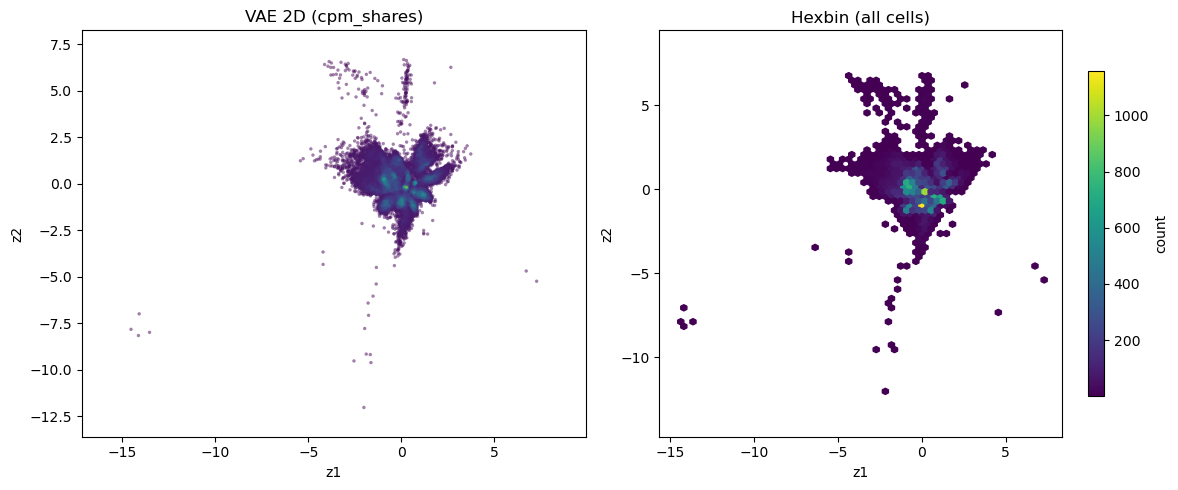

              z1         z2
count  27219.000  27219.000
mean      -0.001      0.007
std        1.027      1.010
min      -14.532    -12.021
25%       -0.753     -0.680
50%       -0.015     -0.046
75%        0.742      0.537
max        7.280      6.769


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    plot_df["z1"], plot_df["z2"],
    c=plot_df["density"], s=6, cmap="viridis", alpha=0.5, linewidths=0,
)
axes[0].set_xlabel("z1"); axes[0].set_ylabel("z2")
axes[0].set_title(f"VAE 2D ({NORM_MODE})")
axes[0].set_aspect("equal", adjustable="datalim")

hb = axes[1].hexbin(
    latent["z1"], latent["z2"],
    gridsize=60, cmap="viridis", mincnt=1,
)
axes[1].set_xlabel("z1"); axes[1].set_ylabel("z2")
axes[1].set_title("Hexbin (all cells)")
axes[1].set_aspect("equal", adjustable="datalim")
fig.colorbar(hb, ax=axes[1], shrink=0.8, label="count")

plt.tight_layout()
plt.show()
print(latent[["z1", "z2"]].describe().round(3))

In [68]:
from plots import *
plot_3d_kde(latent.T, 'z1', 'z2') #4

In [74]:
plot_3d_kde(merged, '7', '10') #4

<Axes: >

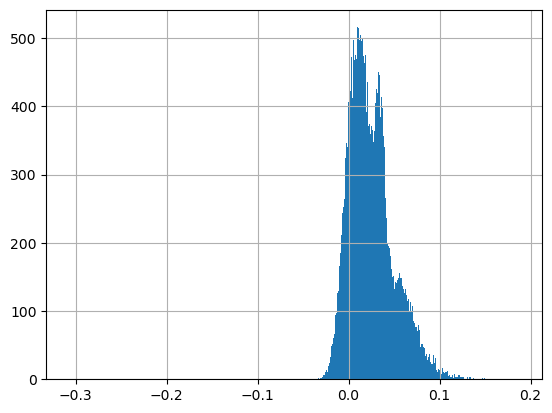

In [73]:
merged.loc['diff_7_minus_10'].hist(bins=500)